# M1 里程碑：心脏病预测

**目标**：用临床指标预测患者是否患有心脏病，并回答「哪些指标最能预警心脏病」。

**数据**：UCI Heart Disease，297 条，13 个特征。`target=1` 表示**有**心脏病。

> 用法：每个格子按 `Shift + Enter` 运行。全部写完后，**Restart & Run All 必须能一遍跑通**再传 GitHub。

## 第 0 格 · 准备环境（已填好，直接跑）

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
print('环境 OK，pandas 版本:', pd.__version__)

环境 OK，pandas 版本: 3.0.3


## Step 1 · 读数据

**验收标准**：能说出数据几行几列、target 里 0 和 1 各代表什么、各有多少条。

> 先搞清楚 **target=1 是有病还是没病**，后面所有指标都建立在这上面。

In [37]:
df = pd.read_csv('heart_disease_clean.csv')

print('形状(行,列):', df.shape)
print()
print('前5行:')
df.head()

形状(行,列): (297, 14)

前5行:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [38]:
# 看每列的类型 + 有没有缺失
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 32.6 KB


In [39]:
# 关键：确认标签含义和分布
print(df['target'].value_counts())
print()
print('0 = 无心脏病, 1 = 有心脏病')

target
0    160
1    137
Name: count, dtype: int64

0 = 无心脏病, 1 = 有心脏病


## Step 2 · EDA 画图（至少 3 张）

**验收标准**：能用一句话说出「有病组和无病组在 XX 上明显不同」。

> 图里的标题和轴标签请用英文，matplotlib 默认不支持中文，写了会变方块。

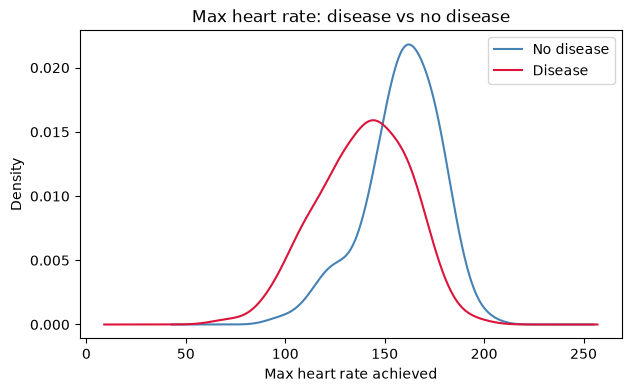

In [40]:
# 图1：最大心率的分布对比
plt.figure(figsize=(7,4))
df[df.target==0]['thalach'].plot(kind='kde', label='No disease', color='steelblue')
df[df.target==1]['thalach'].plot(kind='kde', label='Disease', color='crimson')
plt.xlabel('Max heart rate achieved')
plt.title('Max heart rate: disease vs no disease')
plt.legend()
plt.show()

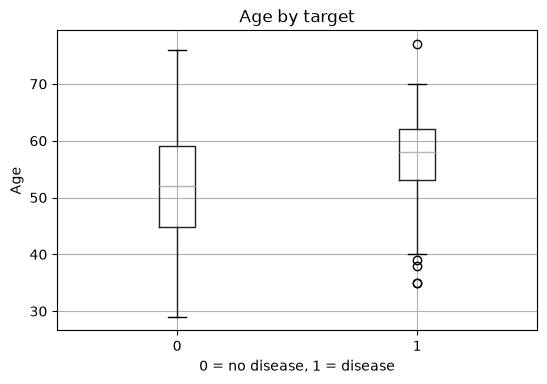

In [41]:
# 图2：年龄的箱线图对比
df.boxplot(column='age', by='target', figsize=(6,4))
plt.title('Age by target')
plt.suptitle('')#清掉pandas 自动加的副标题
plt.xlabel('0 = no disease, 1 = disease')
plt.ylabel('Age')
plt.show()

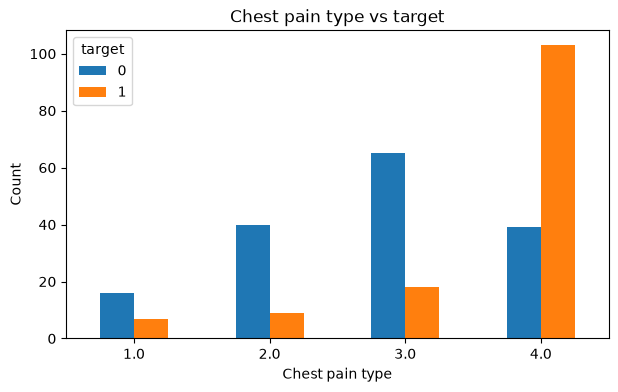

In [42]:
# 图3：胸痛类型的分布对比（类别变量用柱状图）
pd.crosstab(df['cp'], df['target']).plot(kind='bar', figsize=(7,4))
plt.title('Chest pain type vs target')
plt.xlabel('Chest pain type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**这里写一句你的发现**（双击这个格子改）：

> 我发现：有病组的最大心率明显更低，说明心脏疾病影响心脏跳动频率

## Step 3 · 类别变量：一热编码

需处理 4 个：`cp` `restecg` `slope` `thal`

**为什么**：`cp` 的 1/2/3/4 只是编号，不存在「4 比 1 严重三倍」的关系。直接丢给模型就是给算法灌了错误假设。

**验收标准**：能解释 4 类变量为什么变成 3 列（`drop_first=True` 的作用）。

In [43]:
cat_cols = ['cp', 'restecg', 'slope', 'thal']
print('编码前:', X_test.shape if False else '')
print('原始列数:', df.shape[1] - 1)

X = pd.get_dummies(df.drop('target', axis=1),
                   columns=cat_cols,
                   drop_first=True)

print('编码后列数:', X.shape[1])
print()
print(list(X.columns))

编码前: 
原始列数: 13
编码后列数: 18

['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0']


## Step 4 · 切分训练集/测试集

这次比上次多一个 **`stratify=y`**：强制两边「有病/无病」比例跟总体一致。数据量才 297 条，不设它测试集可能畸形。

In [44]:
from sklearn.model_selection import train_test_split

y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('训练集:', X_train.shape, ' 有病比例: %.3f' % y_train.mean())
print('测试集:', X_test.shape, ' 有病比例: %.3f' % y_test.mean())
print()
print('两边比例接近 -> stratify 生效了')

训练集: (237, 18)  有病比例: 0.460
测试集: (60, 18)  有病比例: 0.467

两边比例接近 -> stratify 生效了


## Step 5 · 三个模型对比

**两个致命坑：**

**坑1 · 这次 `pos_label=1`**
上次乳腺癌 `malignant=0` 要写 `pos_label=0`；这次 target=1 才是有病，所以要写 **1**。
> 规矩：拿到任何数据集先确认正类编码是几，再写 pos_label。记这个动作，别记数字。

**坑2 · 不能用准确率**
全猜「无病」准确率也有 54%。主指标用**召回率**，因为**漏诊比误诊贵**。

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, make_scorer
from sklearn.model_selection import cross_val_score

# 关键：pos_label=1，因为有病=1
scorer = make_scorer(recall_score, pos_label=1)

models = {
    'LogisticRegression': LogisticRegression(max_iter=10000),
    'DecisionTree':       DecisionTreeClassifier(random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=300, random_state=42),
}

results = []
for name, m in models.items():
    cv_recall = cross_val_score(m, X_train, y_train, cv=5, scoring=scorer).mean()
    m.fit(X_train, y_train)
    test_recall = recall_score(y_test, m.predict(X_test), pos_label=1)
    results.append({'模型': name, '交叉验证召回率': round(cv_recall,3), '测试集召回率': round(test_recall,3)})

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
print()
print('召回率 = 有病的人里，被模型揪出来的比例')

                模型  交叉验证召回率  测试集召回率
LogisticRegression    0.769   0.821
      DecisionTree    0.770   0.607
      RandomForest    0.760   0.786

召回率 = 有病的人里，被模型揪出来的比例


## Step 6 · 混淆矩阵，手算一遍

**验收标准**：手算 TP/(TP+FN) 跟 `recall_score` 输出对得上。

In [46]:
from sklearn.metrics import confusion_matrix, classification_report

best = RandomForestClassifier(n_estimators=300, random_state=42)
best.fit(X_train, y_train)
y_pred = best.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print('混淆矩阵:')
print(cm)
print()
tn, fp, fn, tp = cm.ravel()
print('TN 真阴性(无病判对):', tn)
print('FP 假阳性(误诊)    :', fp)
print('FN 假阴性(漏诊!)   :', fn, ' <- 最贵的错误')
print('TP 真阳性(有病判对):', tp)
print()
print('手算召回率 = TP/(TP+FN) = %d/(%d+%d) = %.3f' % (tp, tp, fn, tp/(tp+fn)))
print('函数输出                = %.3f' % recall_score(y_test, y_pred, pos_label=1))
print()
print(classification_report(y_test, y_pred, target_names=['No disease','Disease']))

混淆矩阵:
[[28  4]
 [ 6 22]]

TN 真阴性(无病判对): 28
FP 假阳性(误诊)    : 4
FN 假阴性(漏诊!)   : 6  <- 最贵的错误
TP 真阳性(有病判对): 22

手算召回率 = TP/(TP+FN) = 22/(22+6) = 0.786
函数输出                = 0.786

              precision    recall  f1-score   support

  No disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



## Step 7 · 特征重要性（最值钱的产出）

出图 + 写一段临床解读。这张图是给非技术背景的人看的。

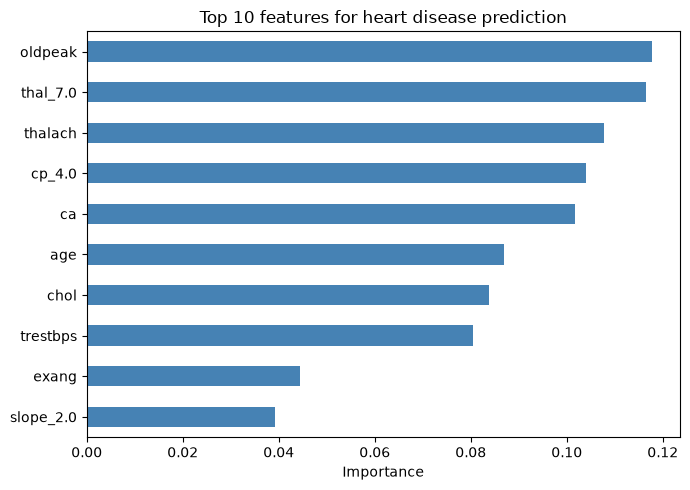

oldpeak      0.1177
thal_7.0     0.1165
thalach      0.1078
cp_4.0       0.1040
ca           0.1017
age          0.0870
chol         0.0839
trestbps     0.0805
exang        0.0444
slope_2.0    0.0393


In [47]:
importances = pd.Series(best.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('Top 10 features for heart disease prediction')
plt.tight_layout()
plt.show()

print(top10.round(4).to_string())

**写你的临床解读**（双击编辑）：

> 模型认为最强的预警信号是 __ 和 __，这与临床上「……」的认识一致；
> __ 排在第三，说明……具有独立价值。 模型认为最强的预警信号是 oldpeak（运动引起的 ST 段压低） 和 thal_7.0（可逆性心肌灌注缺陷），这与临床上「心肌缺血时 ST 段改变是最直接的客观证据」的认识一致。thalach（最大心率）排第 3、cp_4.0（无症状型胸痛）排第 4，这两个特征在 EDA 阶段就已显示出与患病的明显关联，说明模型学到的是真实规律而非噪声。值得注意的是 cp_4.0 的高重要性——它对应「无症状」人群，反而提示最高的患病风险，这与临床上无症状心肌缺血易被忽视、后果更凶险的现象吻合。
局限：本数据集仅 297 条，特征重要性存在波动；且重要性只反映统计关联，不能直接推断因果。

## 自查清单

- [ ] 能说清 target 里 0 和 1 分别代表什么
- [ ] 知道为什么这次 `pos_label=1`
- [ ] 画了至少 3 张 EDA 图，能说出一个发现
- [ ] 做了一热编码，能解释 `drop_first`
- [ ] 三个模型都跑了交叉验证
- [ ] 主指标是召回率，能说出为什么不用准确率
- [ ] 手算过召回率，跟函数输出对得上
- [ ] 出了特征重要性图 + 临床解读
- [ ] Restart & Run All 能一遍跑通
- [ ] GitHub README 五块齐全

> 别追求完美，追求完成。